# BrainInsight AI
# Notebook 02: Image Preprocessing

## Objectives
Apply preprocessing: Resize, Grayscale, Histogram Equalization, Gaussian Blur, Otsu Thresholding, Morphological Opening and Closing. Save processed images while preserving dataset structure.

In [1]:
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT=Path("..")
DATASET_DIR=PROJECT_ROOT/'dataset'
OUTPUT_DIR=PROJECT_ROOT/'Preprocessed'
TRAIN_DIR=DATASET_DIR/'Training'
TEST_DIR=DATASET_DIR/'Testing'
TARGET_SIZE=(256,256)


## Preprocessing Function

In [2]:
def preprocess_image(image_path,size=TARGET_SIZE):
    img=cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f'Cannot read {image_path}')
    resized=cv2.resize(img,size)
    gray=cv2.cvtColor(resized,cv2.COLOR_BGR2GRAY)
    equalized=cv2.equalizeHist(gray)
    blurred=cv2.GaussianBlur(equalized,(5,5),0)
    _,thresh=cv2.threshold(blurred,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    kernel=np.ones((3,3),np.uint8)
    opened=cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel)
    closed=cv2.morphologyEx(opened,cv2.MORPH_CLOSE,kernel)
    return {'original':img,'resized':resized,'gray':gray,'equalized':equalized,'blurred':blurred,'threshold':thresh,'opened':opened,'closed':closed}


## Visualize Pipeline

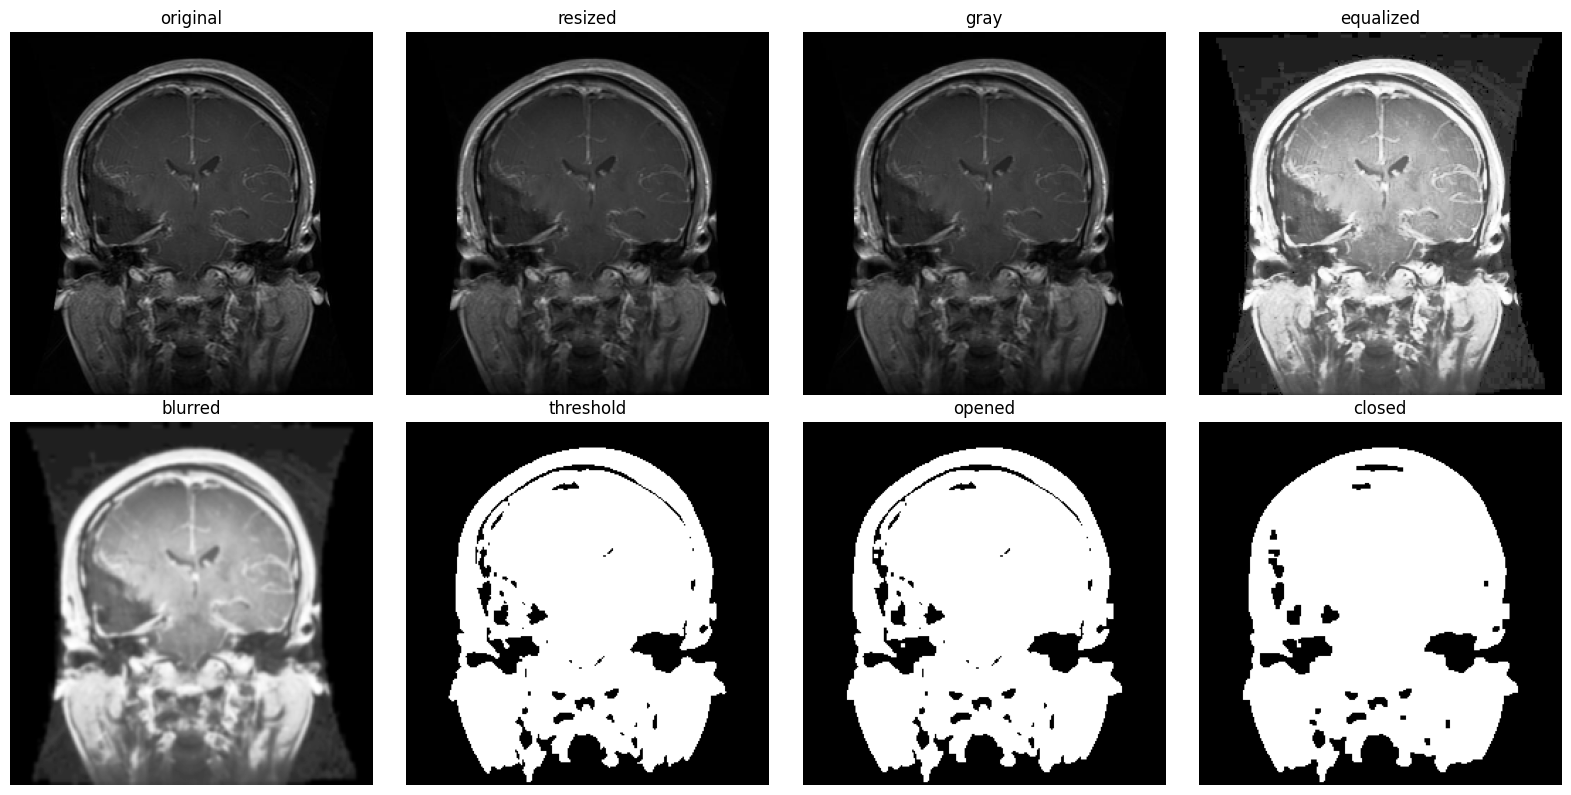

In [3]:
sample=None
for split in [TRAIN_DIR,TEST_DIR]:
    if split.exists():
        for cls in sorted(os.listdir(split)):
            p=split/cls
            if p.is_dir():
                imgs=list(p.glob('*'))
                if imgs:
                    sample=imgs[0]
                    break
        if sample:
            break

steps=preprocess_image(sample)
titles=list(steps.keys())
fig,axes=plt.subplots(2,4,figsize=(16,8))
for ax,title in zip(axes.flatten(),titles):
    im=steps[title]
    if len(im.shape)==2:
        ax.imshow(im,cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Process Entire Dataset

In [4]:
def process_split(input_dir,output_dir):
    processed=0
    failed=0
    if not input_dir.exists():
        return processed,failed
    for cls in sorted(os.listdir(input_dir)):
        cdir=input_dir/cls
        if not cdir.is_dir():
            continue
        sdir=output_dir/cls
        sdir.mkdir(parents=True,exist_ok=True)
        for file in tqdm(list(cdir.iterdir()),desc=f'{input_dir.name}-{cls}'):
            if file.suffix.lower() not in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']:
                continue
            try:
                result=preprocess_image(file)
                cv2.imwrite(str(sdir/file.name),result['closed'])
                processed+=1
            except Exception:
                failed+=1
    return processed,failed

OUTPUT_DIR.mkdir(exist_ok=True)
tp,tf=process_split(TRAIN_DIR,OUTPUT_DIR/'Training')
vp,vf=process_split(TEST_DIR,OUTPUT_DIR/'Testing')
print(f'Training Processed: {tp}')
print(f'Testing Processed : {vp}')
print(f'Failed Images     : {tf+vf}')


Training-glioma:   2%|▏         | 24/1400 [00:00<00:05, 239.73it/s]

Testing-pituitary: 100%|██████████| 400/400 [00:01<00:00, 244.54it/s]

Training Processed: 5600
Testing Processed : 1600
Failed Images     : 0


## Conclusion
The preprocessed images are stored in the `Preprocessed` folder and are ready for handcrafted feature extraction in the next notebook.

## Interview Notes
- Why resize images?
- Why grayscale?
- Why histogram equalization?
- Why Gaussian blur before thresholding?
- Why morphological opening and closing?